In [1]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

In [2]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# add labels
fake["label"] = 1      # fake news
real["label"] = 0      # real news

# stack them together
combined = pd.concat([fake, real], ignore_index=True)

# check
print(combined.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      1  
1  December 31, 2017      1  
2  December 30, 2017      1  
3  December 29, 2017      1  
4  December 25, 2017      1  


In [3]:
combined['date'] = pd.to_datetime(combined['date'], errors='coerce')
combined = combined.sort_values('date')
weekly = (
    combined[combined['label'] == 1]
    .groupby(pd.Grouper(key='date', freq='W'))
    .size()
    .reset_index(name='fake_count')
)

In [4]:
threshold = weekly['fake_count'].quantile(0.70)
weekly['spike'] = (weekly['fake_count'] > threshold).astype(int)

In [5]:
#Remembering the past weeks

weekly['lag1'] = weekly['fake_count'].shift(1)
weekly['lag2'] = weekly['fake_count'].shift(2)
weekly['lag3'] = weekly['fake_count'].shift(3)


#On average, how bad has misinformation been recently?
weekly["roll_mean_3"] = weekly["fake_count"].rolling(window=3).mean()
weekly["roll_mean_5"] = weekly["fake_count"].rolling(window=5).mean()


#Total bursts
weekly["roll_sum_3"] = weekly["fake_count"].rolling(window=3).sum()
weekly["roll_sum_5"] = weekly["fake_count"].rolling(window=5).sum()

#How much higher compared to before
weekly["momentum"] = weekly["fake_count"] - weekly["fake_count"].shift(3)

weekly = weekly.dropna()

In [6]:
weekly = weekly.sort_values("date").reset_index(drop=True)

X = weekly[
    [
        "lag1", "lag2", "lag3",
        "roll_mean_3", "roll_mean_5",
        "roll_sum_3", "roll_sum_5",
        "momentum"
    ]
]
y = weekly['spike']

test_size = 40

X_train = X.iloc[:-test_size]
y_train = y.iloc[:-test_size]

X_test  = X.iloc[-test_size:]
y_test  = y.iloc[-test_size:]

print("Test label distribution:")
print(y_test.value_counts())

Test label distribution:
spike
0    36
1     4
Name: count, dtype: int64


In [7]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_classifier = xgb.XGBClassifier(random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy : {test_accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy : 0.9750

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.90      0.99      0.94        40
weighted avg       0.98      0.97      0.98        40


Confusion Matrix:
 [[35  1]
 [ 0  4]]


In [9]:
#Use hyperparameter training. Set parameters manually for higher accuracy.

param_grid = {  #hyper parameters below
    'n_estimators': [100, 200, 300, 500], #number of trees
    'learning_rate': [0.01, 0.1, 0.2],  #rate at which model changes
    'max_depth': [3, 6, 9], #how deep tree can get
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],  #controls no. of observations used to make each tree
    'colsample_bytree': [0.7, 0.85, 1.0],   #how many features used per tree. Smaller -> less complex
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]    #don't set too low
}

xgb_model = xgb.XGBClassifier(random_state = 42)
#cross validation. 10 cross validation folds (short of cv)

#gridsearchCV will take long : every combination of parameters and loops through all of them
#RandomizedSearchCV : Gives faster process

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42) #n_iter : how many combos to search
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_      #return with best parameters. gives higher accuracy score

# Best parameters from tuning
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Parameters: {'subsample': 0.85, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best Accuracy: 0.8622222222222222


In [10]:
#Testing Now to X_Test
print(y_test.value_counts())
y_pred = best_xgb.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

spike
0    36
1     4
Name: count, dtype: int64
Test Accuracy: 0.9750

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.80      1.00      0.89         4

    accuracy                           0.97        40
   macro avg       0.90      0.99      0.94        40
weighted avg       0.98      0.97      0.98        40


Confusion Matrix:
 [[35  1]
 [ 0  4]]


In [11]:
#Saving my best configurated parameters into this file so my trained model is saved
import pickle

with open("misinfo_spike_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

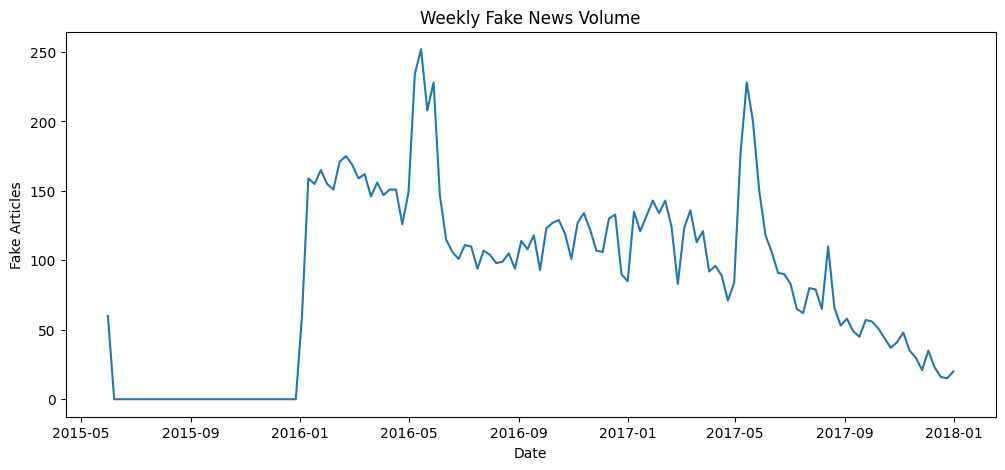

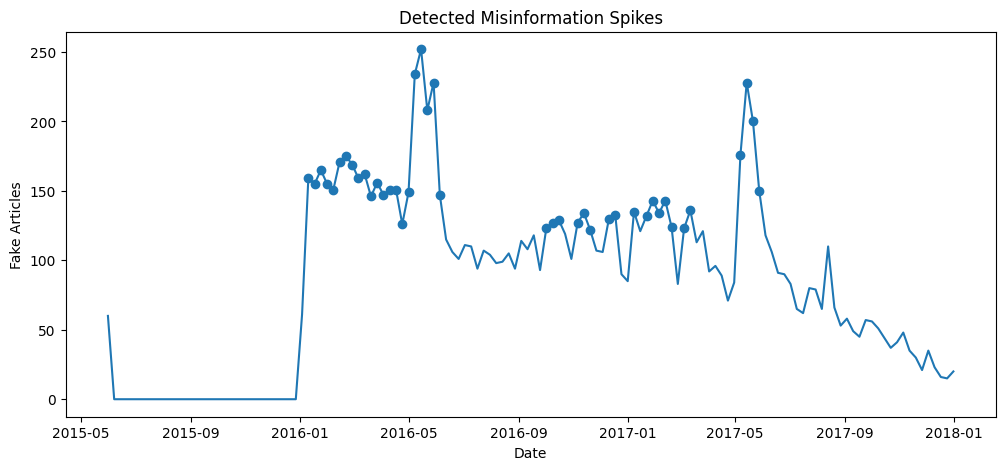

In [12]:
#Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(weekly['date'], weekly['fake_count'])
plt.title("Weekly Fake News Volume")
plt.xlabel("Date")
plt.ylabel("Fake Articles")
plt.show()

spikes = weekly[weekly['spike'] == 1]

plt.figure(figsize=(12,5))
plt.plot(weekly['date'], weekly['fake_count'])
plt.scatter(spikes['date'], spikes['fake_count'], marker='o')
plt.title("Detected Misinformation Spikes")
plt.xlabel("Date")
plt.ylabel("Fake Articles")
plt.show()

In [13]:
#Flask acts as a mini server. This makes it so that we can run this model witbhout booting up Jupyter and allthat

from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

# load model
with open("misinfo_spike_model.pkl", "rb") as f:
    model = pickle.load(f)

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    
    lag1 = data["lag1"]
    lag2 = data["lag2"]
    lag3 = data["lag3"]

    features = np.array([[lag1, lag2, lag3]])

    pred = model.predict(features)[0]

    return jsonify({
        "prediction": int(pred),
        "meaning": "Spike likely" if pred == 1 else "Normal week"
    })

if __name__ == "__main__":
    app.run(debug=True)
#FD

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

c:\Users\Wilson\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# =========================
# 1️⃣ Imports
# =========================
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


# =========================
# 2️⃣ Load Data
# =========================
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# Add labels (fake = 1, real = 0)
fake["label"] = 1
real["label"] = 0

combined = pd.concat([fake, real], ignore_index=True)

# Convert date column
combined["date"] = pd.to_datetime(combined["date"], errors="coerce")


# =========================
# 3️⃣ Aggregate into Weekly Fake Counts
# =========================
weekly = (
    combined[combined["label"] == 1]
    .set_index("date")
    .resample("W")
    .size()
    .reset_index(name="fake_count")
)


# =========================
# 4️⃣ Create Spike Label (choose reasonable threshold)
# =========================
for q in [0.50, 0.60, 0.70, 0.80, 0.90]:
    t = weekly["fake_count"].quantile(q)
    spikes = (weekly["fake_count"] > t).sum()
    print(f"Quantile {q}: threshold={t:.1f}, spikes={spikes}")

threshold = weekly["fake_count"].quantile(0.60)
weekly["spike"] = (weekly["fake_count"] > threshold).astype(int)


# =========================
# 5️⃣ Temporal Features (lags)
# =========================
weekly["lag1"] = weekly["fake_count"].shift(1)
weekly["lag2"] = weekly["fake_count"].shift(2)
weekly["lag3"] = weekly["fake_count"].shift(3)

weekly = weekly.dropna()

X = weekly[["lag1", "lag2", "lag3"]]
y = weekly["spike"]


# =========================
# 6️⃣ Time-based Split (NO SHUFFLING)
# =========================
split_point = int(len(X) * 0.70)

X_train = X.iloc[:split_point]
y_train = y.iloc[:split_point]

X_test = X.iloc[split_point:]
y_test = y.iloc[split_point:]

from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# =========================
# Hyperparameter tuning
# =========================
param_grid = {  
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss"
)

grid_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    cv=10,
    scoring="accuracy",
    n_iter=100,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# retrain on full training data
best_xgb.fit(X_train, y_train)

# evaluate
y_pred = best_xgb.predict(X_test)

print("\nFINAL TEST ACCURACY:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("\nCounts per split:")
print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())


# =========================
# 7️⃣ Handle Imbalance (spikes are rare)
# =========================
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("\nClass weight ratio:", ratio)


# =========================
# 8️⃣ Train Model
# =========================
model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    scale_pos_weight=ratio          # <<< IMPORTANT
)

model.fit(X_train, y_train)


# =========================
# 9️⃣ Evaluate
# =========================
y_pred = model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


# =========================
# 🔮 10️⃣ FUTURE SPIKE PREDICTION
# =========================
def predict_future_spikes(weekly_df, model, n_weeks=6):
    df = weekly_df.copy()
    future_predictions = []

    for i in range(n_weeks):
        # latest lags
        lag1 = df["fake_count"].iloc[-1]
        lag2 = df["fake_count"].iloc[-2]
        lag3 = df["fake_count"].iloc[-3]

        X_future = np.array([[lag1, lag2, lag3]])
        pred_spike = model.predict(X_future)[0]

        predicted_fake_count = df["fake_count"].iloc[-1]
        next_date = df["date"].iloc[-1] + pd.to_timedelta(7, unit="D")

        future_predictions.append({
            "date": next_date,
            "predicted_spike": int(pred_spike),
            "estimated_fake_count": int(predicted_fake_count)
        })

        # add new row for rolling prediction
        df = pd.concat([
            df,
            pd.DataFrame({
                "date": [next_date],
                "fake_count": [predicted_fake_count]
            })
        ], ignore_index=True)

    return pd.DataFrame(future_predictions)


future = predict_future_spikes(weekly, model, n_weeks=6)

print("\n🔮 FUTURE FORECAST:")
print(future)


Quantile 0.5: threshold=92.0, spikes=69
Quantile 0.6: threshold=106.4, spikes=56
Quantile 0.7: threshold=121.3, spikes=42
Quantile 0.8: threshold=135.2, spikes=28
Quantile 0.9: threshold=156.3, spikes=14
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Parameters: {'subsample': 0.85, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV Accuracy: 0.8133333333333332

FINAL TEST ACCURACY: 0.8095238095238095

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.88        34
           1       0.50      0.75      0.60         8

    accuracy                           0.81        42
   macro avg       0.72      0.79      0.74        42
weighted avg       0.85      0.81      0.82        42


Confusion Matrix:
 [[28  6]
 [ 2  6]]

Counts per split:
Train: spike
1    48
0    47
Name: count, dtype: int64
Test: spi

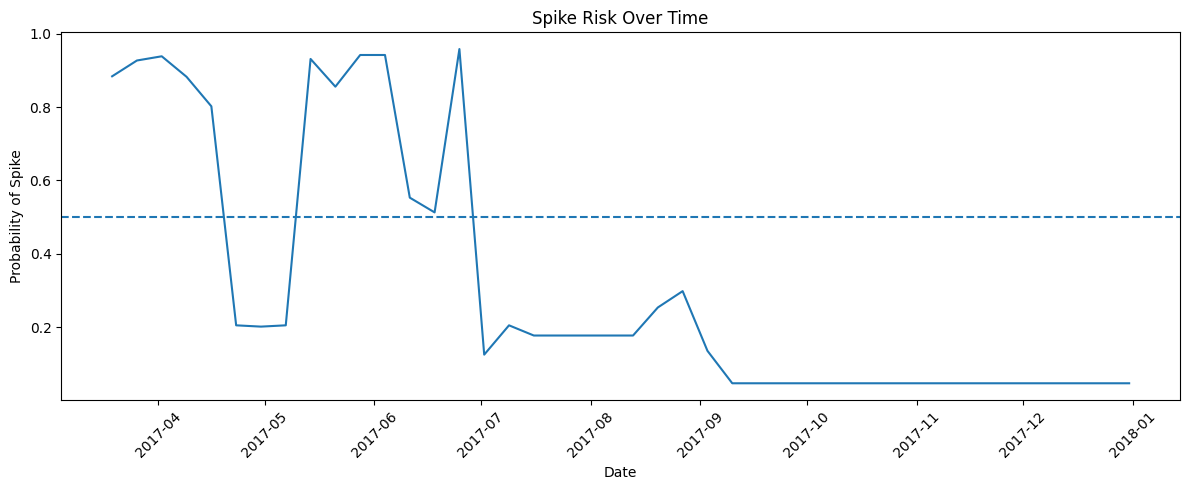

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Spike probability over time
# =========================
weekly_plot = weekly.iloc[len(weekly) - len(y_test):].copy()

probs = best_xgb.predict_proba(X_test)[:, 1]
weekly_plot["spike_probability"] = probs

plt.figure(figsize=(12,5))
plt.plot(weekly_plot["date"], weekly_plot["spike_probability"])
plt.axhline(0.5, linestyle="--")  # decision boundary
plt.title("Spike Risk Over Time")
plt.xlabel("Date")
plt.ylabel("Probability of Spike")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
# =========================
# 🔎 TOPIC MODELING FOR SPIKES
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re

# -------------------------
# 1) PREP TEXT DATA WEEKLY
# -------------------------

# keep only fake
fake_only = combined[combined["label"] == 1].copy()

# basic cleaning
def clean_text(t):
    if isinstance(t, str):
        t = t.lower()
        t = re.sub(r"http\S+", "", t)
        t = re.sub(r"[^a-z\s]", " ", t)
        return t
    return ""

fake_only["clean_text"] = fake_only["title"].fillna("").apply(clean_text)

# group text BY WEEK
weekly_text = (
    fake_only
        .set_index("date")
        .resample("W")["clean_text"]
        .apply(lambda x: " ".join(x))
        .reset_index()
)

weekly_text.columns = ["date", "text"]

# merge with weekly spike dataframe
topics_df = weekly.merge(weekly_text, on="date", how="left")

# keep only rows that actually have text
topics_df = topics_df[topics_df["text"].str.len() > 0]


# -------------------------
# 2) TF-IDF VECTORIZE
# -------------------------
vectorizer = TfidfVectorizer(
    max_features=6000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3
)

tfidf_matrix = vectorizer.fit_transform(topics_df["text"])


# -------------------------
# 3) RUN TOPIC MODELING (LDA)
# -------------------------
n_topics = 6   # you can change this later

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(tfidf_matrix)

feature_names = vectorizer.get_feature_names_out()


def show_topics(model, feature_names, n_top_words=12):
    topics = []
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append(top_words)
        print(f"\n🟡 TOPIC {idx+1}:")
        print(", ".join(top_words))
    return topics

topics = show_topics(lda, feature_names)


# -------------------------
# 4) ASSIGN TOPIC TO EACH WEEK
# -------------------------
topic_values = lda.transform(tfidf_matrix)
topics_df["dominant_topic"] = topic_values.argmax(axis=1)

# look at ONLY SPIKE WEEKS
spike_topics = topics_df[topics_df["spike"] == 1]

print("\n============================")
print("🔥 TOP TOPICS DURING SPIKES")
print("============================")

topic_counts = spike_topics["dominant_topic"].value_counts()

for topic_id, count in topic_counts.items():
    words = ", ".join(topics[topic_id][:8])
    print(f"\nTopic {topic_id+1} ({count} spike weeks):")
    print(f"➡ {words}")



🟡 TOPIC 1:
tiffany, mcconnell says, media told, liar video, controversial, raises, sides, outrageous claim, hard time, features, qb, eve

🟡 TOPIC 2:
tiffany, mcconnell says, media told, liar video, controversial, raises, sides, outrageous claim, hard time, features, qb, eve

🟡 TOPIC 3:
trump, video, watch, just, obama, hillary, gop, donald, donald trump, tweets, news, clinton

🟡 TOPIC 4:
tiffany, mcconnell says, media told, liar video, controversial, raises, sides, outrageous claim, hard time, features, qb, eve

🟡 TOPIC 5:
tiffany, mcconnell says, media told, liar video, controversial, raises, sides, outrageous claim, hard time, features, qb, eve

🟡 TOPIC 6:
tiffany, mcconnell says, media told, liar video, controversial, raises, sides, outrageous claim, hard time, features, qb, eve

🔥 TOP TOPICS DURING SPIKES

Topic 3 (42 spike weeks):
➡ trump, video, watch, just, obama, hillary, gop, donald


In [27]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

# -------------------------------
# 1️⃣ Build texts safely
# -------------------------------

# Make sure these column names match your notebook exactly
# (title, text, spike)
df_topics = combined.copy()

# Replace obvious non-strings with ""
df_topics["title"] = df_topics["title"].replace({np.nan: ""}).astype(str)
df_topics["text"] = df_topics["text"].replace({np.nan: ""}).astype(str)

# Combine fields
df_topics["full_text"] = (df_topics["title"] + " " + df_topics["text"]).str.strip()

# Keep only spike weeks
spike_texts = df_topics.loc[df_topics["label"] == 1, "full_text"]

# Drop empty or weird rows
spike_texts = spike_texts[spike_texts.str.len() > 5]

# FINAL clean list for BERTopic
spike_texts = spike_texts.tolist()

print(f"Training on {len(spike_texts)} spike articles")

# -------------------------------
# 2️⃣ Train BERTopic
# -------------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    low_memory=True,
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(spike_texts)

# -------------------------------
# 3️⃣ Inspect topics
# -------------------------------
print("\nTOP 10 TOPICS:")
topic_model.get_topic_info().head(10)

# -------------------------------
# 4️⃣ Visualizations
# -------------------------------
topic_model.visualize_topics()

topic_model.visualize_barchart(
    top_n_topics=10,
    n_words=10
)

topic_model.visualize_heatmap()


Training on 23481 spike articles


2025-12-29 13:46:31,795 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/734 [00:00<?, ?it/s]

2025-12-29 13:56:52,409 - BERTopic - Embedding - Completed ✓
2025-12-29 13:56:52,410 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-29 13:57:18,181 - BERTopic - Dimensionality - Completed ✓
2025-12-29 13:57:18,183 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-29 13:57:22,801 - BERTopic - Cluster - Completed ✓
2025-12-29 13:57:22,802 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-29 13:57:29,376 - BERTopic - Representation - Completed ✓
2025-12-29 13:57:29,381 - BERTopic - Topic reduction - Reducing number of topics
2025-12-29 13:57:29,585 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-29 13:57:35,963 - BERTopic - Representation - Completed ✓
2025-12-29 13:57:35,973 - BERTopic - Topic reduction - Reduced number of topics from 455 to 87



TOP 10 TOPICS:


In [33]:
# ============================================================
#  ⭐ CONNECT TOPICS TO SPIKE FORECASTS
#  - Assign topics to weeks
#  - Merge topics with spike predictors
#  - Predict: (1) Spike?  (2) Likely Topic
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# ------------------------------------------------------------
# 1️⃣ SAFETY: make sure key columns exist
# ------------------------------------------------------------
needed = ["date", "title", "text", "label"]
missing = [c for c in needed if c not in combined.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df_topics = combined.copy()

# Clean text
df_topics["title"] = df_topics["title"].replace({np.nan: ""}).astype(str)
df_topics["text"] = df_topics["text"].replace({np.nan: ""}).astype(str)

# Combine title + text
df_topics["full_text"] = (
    df_topics["title"].str.strip() + " " + df_topics["text"].str.strip()
).str.strip()

# ------------------------------------------------------------
# 2️⃣ Assign topic to each article using BERTopic
# ------------------------------------------------------------
article_topics, _ = topic_model.transform(df_topics["full_text"])
df_topics["topic"] = article_topics

# ------------------------------------------------------------
# 3️⃣ Convert to WEEK and aggregate to weekly dominant topic
# ------------------------------------------------------------
df_topics["week"] = pd.to_datetime(df_topics["date"]).dt.to_period("W").dt.start_time

# Dominant topic per week = most frequent topic
weekly_topic = (
    df_topics.groupby("week")["topic"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"topic": "dominant_topic"})
)

# ------------------------------------------------------------
# 4️⃣ Build weekly spike dataset (label = spike)
# ------------------------------------------------------------
weekly_spike = (
    df_topics.groupby("week")
    .agg(
        spike=("label", "max")   # 1 if any spike that week
    )
    .reset_index()
)

# ------------------------------------------------------------
# 5️⃣ MERGE: weekly spike + weekly dominant topic
# ------------------------------------------------------------
weekly = weekly_spike.merge(weekly_topic, on="week", how="left")
weekly = weekly.dropna(subset=["dominant_topic"])

# ------------------------------------------------------------
# 6️⃣ ADD YOUR EXISTING PREDICTOR COLUMNS
# ------------------------------------------------------------
# Replace with your numeric predictor columns for spike
predictors = [c for c in weekly.columns if c not in ["week", "spike", "dominant_topic"]]
print("Using predictors:", predictors)

# ------------------------------------------------------------
# 7️⃣ Model A — Predict SPIKE (yes / no)
# ------------------------------------------------------------
X = weekly[predictors]
y_spike = weekly["spike"]

X_train, X_test, y_train, y_test = train_test_split(X, y_spike, test_size=0.2, shuffle=False)

spike_model = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

spike_model.fit(X_train, y_train)

print("\n🔍 Spike Prediction Performance")
print(classification_report(y_test, spike_model.predict(X_test)))

# ------------------------------------------------------------
# 8️⃣ Model B — Predict TOPIC (only when spike=1)
# ------------------------------------------------------------
spike_weeks = weekly[weekly["spike"] == 1].copy()
y_topic = spike_weeks["dominant_topic"]
X_topic = spike_weeks[predictors]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_topic, y_topic, test_size=0.2, shuffle=False
)

topic_model_classifier = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

topic_model_classifier.fit(X_train_t, y_train_t)

print("\n🎯 Topic Prediction (conditional on spike)")
print(classification_report(y_test_t, topic_model_classifier.predict(X_test_t)))

# ------------------------------------------------------------
# 9️⃣ MAKE A FORECAST FUNCTION
# ------------------------------------------------------------
def forecast_next_week(input_row):
    """
    input_row = a single row of predictor values (future week)
    returns: prob spike + likely topic
    """
    spike_prob = spike_model.predict_proba(input_row)[0][1]
    spike_flag = spike_prob >= 0.5

    if not spike_flag:
        return {
            "spike_probability": float(spike_prob),
            "spike_expected": False,
            "topic": None,
            "topic_words": None,
        }

    topic_id = int(topic_model_classifier.predict(input_row)[0])
    topic_words = topic_model.get_topic(topic_id)

    return {
        "spike_probability": float(spike_prob),
        "spike_expected": True,
        "topic": topic_id,
        "topic_words": topic_words
    }

print("\n✅ Ready: call forecast_next_week() with your next-week predictors")


Batches:   0%|          | 0/1404 [00:00<?, ?it/s]

2025-12-29 18:18:34,801 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-29 18:18:50,788 - BERTopic - Dimensionality - Completed ✓
2025-12-29 18:18:50,789 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-29 18:18:55,016 - BERTopic - Cluster - Completed ✓


Using predictors: []


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]